In [1]:
import numpy as np  
import matplotlib.pyplot as plt
import cv2 as cv
import pandas as pd
import os

#ini cara import setiap file dari librarynya
from pcdlib import manimg as img 
from pcdlib import manhist as hist
from pcdlib import manenhc as enhc
from pcdlib import morfimg as morf
from pcdlib import manwave as wave


from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

### Import Library

Pada tahap ini, dilakukan impor berbagai library yang digunakan untuk mendukung proses pengolahan citra digital, ekstraksi fitur, visualisasi data, serta pembangunan dan evaluasi model klasifikasi. Berikut merupakan penjelasan fungsi dari masing-masing library yang digunakan dalam penelitian ini.

| No | Library                                     | Fungsi                                                                                                                         |
| -- | ------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------ |
| 1  | `numpy` (`np`)                              | Digunakan untuk operasi komputasi numerik dan manipulasi array multidimensi yang menjadi dasar dalam pengolahan citra digital. |
| 2  | `matplotlib.pyplot` (`plt`)                 | Digunakan untuk menampilkan visualisasi gambar, histogram, serta grafik hasil analisis data.                                   |
| 3  | `cv2` (`cv`)                                | Library OpenCV yang digunakan untuk membaca, memproses, memanipulasi, dan melakukan transformasi pada citra digital.           |
| 4  | `pandas` (`pd`)                             | Digunakan untuk mengelola dan menganalisis data dalam bentuk tabel atau DataFrame.                                             |
| 5  | `os`                                        | Digunakan untuk berinteraksi dengan sistem operasi, seperti mengakses direktori dan mengelola file dataset.                    |
| 6  | `pcdlib.manimg` (`img`)                     | Modul khusus untuk melakukan manipulasi citra dasar, seperti pembacaan dan pengolahan awal gambar.                             |
| 7  | `pcdlib.manhist` (`hist`)                   | Modul untuk melakukan analisis dan pengolahan histogram citra.                                                                 |
| 8  | `pcdlib.manenhc` (`enhc`)                   | Modul yang digunakan untuk meningkatkan kualitas citra (image enhancement), seperti peningkatan kontras atau kecerahan.        |
| 9  | `pcdlib.morfimg` (`morf`)                   | Modul untuk melakukan operasi morfologi citra, seperti erosi, dilasi, opening, dan closing.                                    |
| 10 | `pcdlib.manwave` (`wave`)                   | Modul untuk melakukan transformasi wavelet dan analisis citra berbasis wavelet.                                                |
| 11 | `sklearn.model_selection.train_test_split`  | Digunakan untuk membagi dataset menjadi data pelatihan (training) dan data pengujian (testing).                                |
| 12 | `sklearn.model_selection.cross_val_predict` | Digunakan untuk melakukan prediksi menggunakan teknik validasi silang (cross-validation).                                      |
| 13 | `skimage.feature.graycomatrix`              | Digunakan untuk membentuk Gray Level Co-occurrence Matrix (GLCM) sebagai dasar ekstraksi fitur tekstur citra.                  |
| 14 | `skimage.feature.graycoprops`               | Digunakan untuk menghitung karakteristik tekstur dari GLCM, seperti contrast, correlation, energy, dan homogeneity.            |
| 15 | `scipy.stats.entropy`                       | Digunakan untuk menghitung nilai entropi yang menggambarkan tingkat kompleksitas atau ketidakteraturan citra.                  |
| 16 | `sklearn.ensemble.RandomForestClassifier`   | Algoritma klasifikasi Random Forest yang memanfaatkan kumpulan decision tree untuk meningkatkan akurasi prediksi.              |
| 17 | `sklearn.svm.SVC`                           | Implementasi algoritma Support Vector Machine (SVM) untuk melakukan klasifikasi data.                                          |
| 18 | `sklearn.neighbors.KNeighborsClassifier`    | Implementasi algoritma K-Nearest Neighbors (KNN) yang mengklasifikasikan data berdasarkan kedekatan antar sampel.              |
| 19 | `sklearn.metrics.accuracy_score`            | Digunakan untuk menghitung tingkat akurasi model klasifikasi.                                                                  |
| 20 | `sklearn.metrics.precision_score`           | Digunakan untuk mengukur ketepatan prediksi positif yang dihasilkan model.                                                     |
| 21 | `sklearn.metrics.recall_score`              | Digunakan untuk mengukur kemampuan model dalam mendeteksi seluruh data positif yang sebenarnya.                                |
| 22 | `sklearn.metrics.f1_score`                  | Digunakan untuk menghitung rata-rata harmonis antara precision dan recall.                                                     |
| 23 | `sklearn.metrics.confusion_matrix`          | Digunakan untuk menampilkan matriks evaluasi yang menunjukkan hasil prediksi model terhadap data aktual.                       |
| 24 | `sklearn.metrics.classification_report`     | Digunakan untuk menghasilkan laporan evaluasi model yang berisi precision, recall, f1-score, dan support.                      |
| 25 | `sklearn.metrics.ConfusionMatrixDisplay`    | Digunakan untuk memvisualisasikan confusion matrix dalam bentuk grafik.                                                        |
| 26 | `seaborn` (`sns`)                           | Digunakan untuk membuat visualisasi data statistik yang lebih informatif dan menarik, seperti heatmap confusion matrix.        |

Berdasarkan library yang digunakan, penelitian ini memanfaatkan kombinasi teknik pengolahan citra digital, ekstraksi fitur tekstur menggunakan GLCM dan entropi, serta beberapa algoritma machine learning (Random Forest, SVM, dan KNN) untuk melakukan proses klasifikasi dan evaluasi performa model.


In [2]:
def resize_image(img_path, size):
    try:
        img = cv.imread(img_path)
        if img is None:
            raise ValueError(f"Image at {img_path} could not be read.")
        resized_img = cv.resize(img, size)
        return resized_img
    except Exception as e:
        print(f"Error resizing image {img_path}: {e}")
        return None

## Fungsi Resize Gambar
Fungsi resize_image(img_path, size) digunakan untuk mengubah ukuran gambar menjadi dimensi tertentu. Proses ini penting agar semua gambar memiliki ukuran yang seragam sebelum diproses lebih lanjut.

Penjelasan:
- cv.imread(img_path): Membaca gambar dari path yang diberikan.
- cv.resize(img, size): Mengubah ukuran gambar ke dimensi yang ditentukan.

Jika gambar tidak bisa dibaca (None), maka akan muncul pesan error. Fungsi akan mengembalikan gambar yang sudah di-resize atau None jika gagal.

### Fungsi Load Dataset
Fungsi load_dataset(dir) bertugas untuk memuat gambar dari folder dataset yang dibagi ke dalam beberapa kelas. Fungsi ini:
Membaca gambar dari masing-masing folder kelas. Lalu melakukan resize gambar menggunakan fungsi sebelumnya (resize_image). terakhir menyimpan gambar dan label ke dalam array.

Penjelasan Utama:
Gambar diresize ke ukuran (256, 256). Maksimal 100 gambar per kelas untuk menjaga proporsi dataset. Keluaran fungsi adalah:
- images: array berisi gambar.
- labels: label dari masing-masing gambar.
- class_names: nama-nama kelas.
- class_counter: jumlah gambar per kelas.

Setelah itu, dilakukan visualisasi jumlah gambar tiap kelas menggunakan seaborn barplot.

Loading dataset...
Dataset loaded with 400 images across 4 classes.


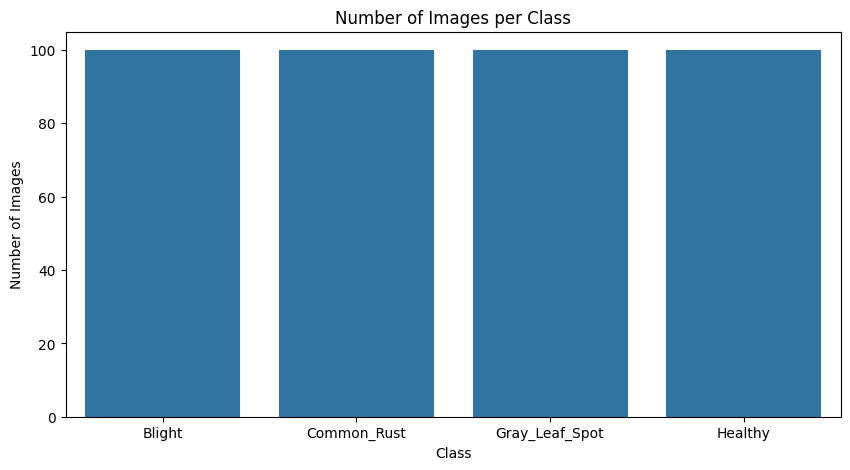

In [3]:
def load_dataset(dir):
    size = (256,256)
    images = []
    labels = []
    class_names = os.listdir(dir)
    class_counter = {class_name: 0 for class_name in class_names}

    for label, class_name in enumerate(class_names):
        class_dir = os.path.join(dir, class_name)
        if os.path.isdir(class_dir):
            for file_name in os.listdir(class_dir):
                if class_counter[class_name] >= 100:
                    break
                img_path = os.path.join(class_dir, file_name)
                img = resize_image(img_path, size)
                if img is not None:
                    images.append(img)
                    labels.append(class_name)
                    class_counter[class_name]+=1
    return np.array(images), np.array(labels), class_names, class_counter


print("Loading dataset...")
images, labels, class_names, class_counter = load_dataset('dataset')
print(f"Dataset loaded with {len(images)} images across {len(class_names)} classes.")
# Diagram Dataset
plt.figure(figsize=(10, 5))
sns.barplot(x=list(class_counter.keys()), y=list(class_counter.values()))
plt.title('Number of Images per Class')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.savefig('dataset_distribution.png')
plt.show()

## Fungsi tampilkan sampel citra
Fungsi show_sample_images(images, labels, class_names) digunakan untuk menampilkan satu gambar sampel dari masing-masing kelas dalam dataset. Hal ini berguna untuk:
- Memverifikasi bahwa gambar telah dimuat dengan benar.
- Memberi gambaran visual dari data yang akan digunakan untuk pelatihan model.

Penjelasan:
images[labels == class_name]: Memfilter gambar berdasarkan label kelas. cv.cvtColor(..., cv.COLOR_BGR2RGB): Mengubah format warna dari BGR (standar OpenCV) ke RGB (standar Matplotlib). Menggunakan plt.subplot untuk menampilkan gambar dalam grid. Hanya ditampilkan satu gambar sampel per kelas (menggunakan index ke-10 dari setiap kelas, jika tersedia).

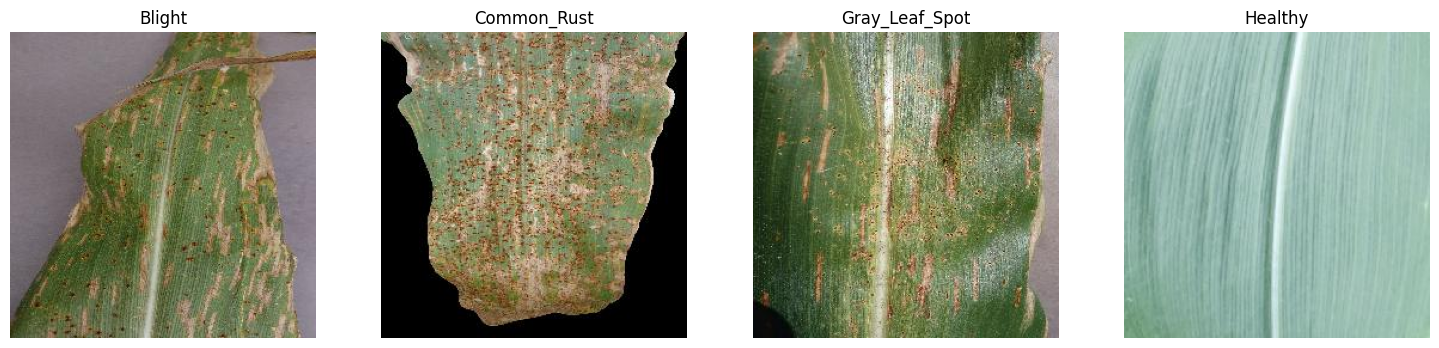

In [4]:
# Menampilkan gambar sample dari setiap kelas
def show_sample_images(images, labels, class_names, cmap =None):
    plt.figure(figsize=(15, 10))
    for i, class_name in enumerate(class_names):
        class_images = images[labels == class_name]
        if len(class_images) > 0:
            plt.subplot(3, 4, i + 1)
            plt.imshow(cv.cvtColor(class_images[10], cv.COLOR_BGR2RGB))
            plt.title(class_name)
            plt.axis('off')
    plt.tight_layout()
    plt.show()
show_sample_images(images, labels, class_names)

Pada bagian ini, kita mengubah seluruh gambar dalam dataset menjadi grayscale.
Penjelasan Langkah:
1. Kita membuat list kosong img_grey untuk menyimpan gambar grayscale.
2. Setiap gambar asli diubah ke grayscale menggunakan cv.cvtColor.
3. Setelah semua gambar diubah, list img_grey dikonversi menjadi array NumPy.
4. Lalu kita tampilkan beberapa gambar grayscale sebagai sampel menggunakan fungsi show_sample_images.

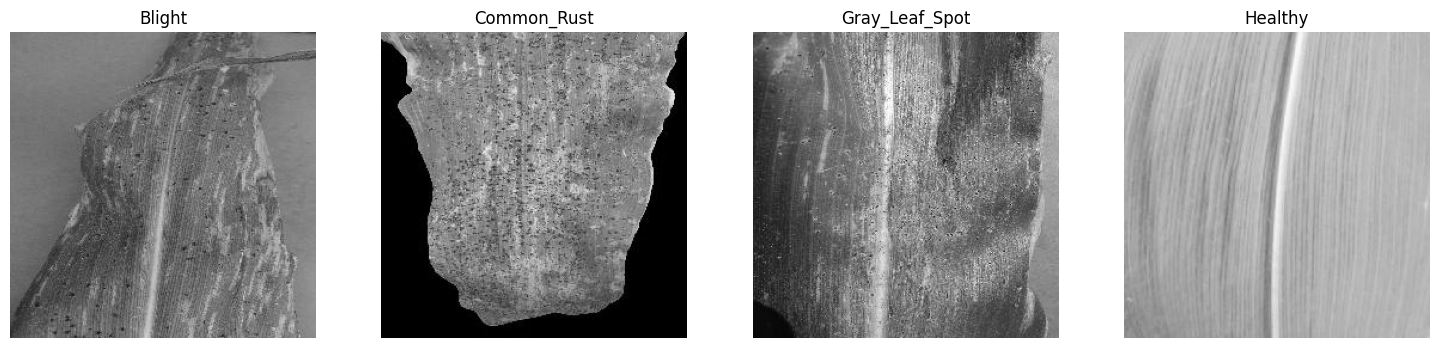

In [5]:
img_grey = []
for img in images:
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img_grey.append(gray)
img_grey = np.array(img_grey)

show_sample_images(img_grey, labels, class_names)

### **PreProcessing 1 (Prewitt & Median)**

#### Deteksi Tepi dengan Prewitt

Tahap ini bertujuan untuk mendeteksi tepi objek pada citra menggunakan operator **Prewitt**.

Cara Kerja:

* Setiap gambar pada `img_grey` diproses menggunakan fungsi `enhc.prewitt()`.
* Hasil deteksi tepi disimpan ke dalam list `img_prewitt`.
* Semua hasil kemudian dikonversi menjadi array NumPy dan ditampilkan menggunakan `show_sample_images()`.

Kenapa Dilakukan?

* Untuk menonjolkan batas objek pada citra.
* Membantu memperjelas bentuk dan struktur objek.
* Mempermudah proses ekstraksi fitur pada tahap selanjutnya.

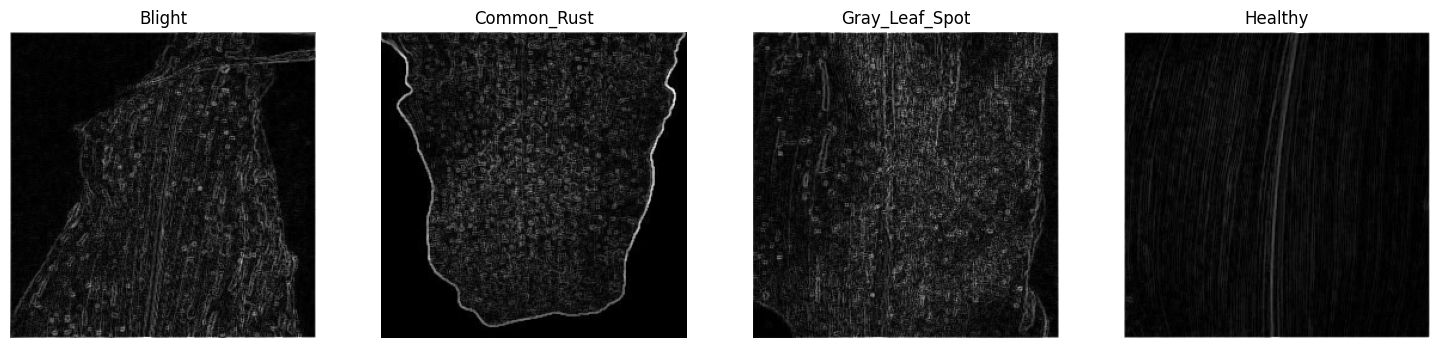

In [6]:
img_prewitt = []

for image in img_grey:

    prewitt = enhc.prewitt(
        image
    )

    img_prewitt.append(
        prewitt
    )

img_prewitt = np.array(
    img_prewitt
)

show_sample_images(
    img_prewitt,
    labels,
    class_names,
    cmap='gray'
)

#### Filtering dengan Median Filter

Tahap ini bertujuan untuk mengurangi noise pada citra hasil deteksi tepi menggunakan **Median Filter**.

Cara Kerja:

* Setiap gambar pada `img_prewitt` difilter menggunakan `enhc.filter()` dengan kernel 3×3 dan metode `'median'`.
* Hasil filtering disimpan ke dalam `img_median`.
* Seluruh hasil ditampilkan menggunakan `show_sample_images()`.

Kenapa Dilakukan?

* Mengurangi noise pada citra.
* Mempertahankan detail tepi objek.
* Meningkatkan kualitas citra sebelum ekstraksi fitur.

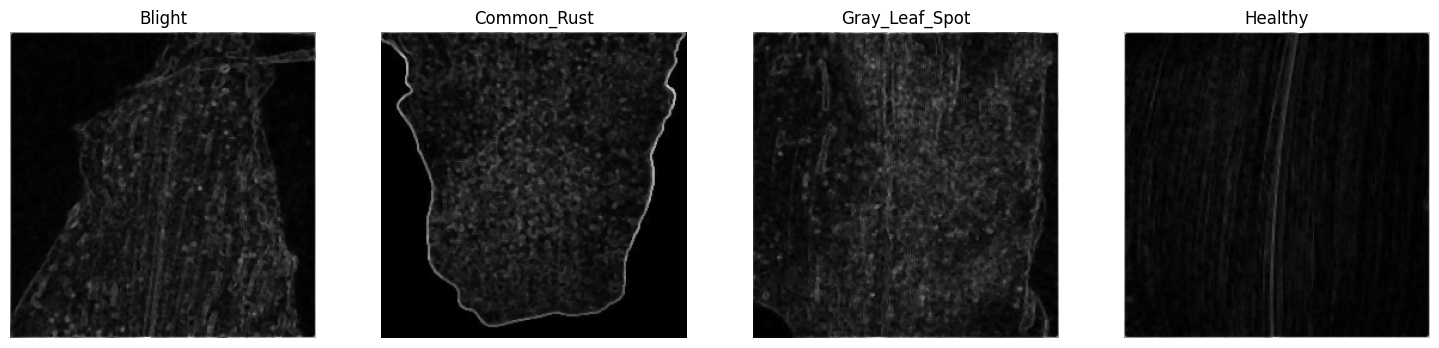

In [ ]:
img_median = []

for image in img_prewitt:

    median = enhc.filter(
        image, 
        3,
        'median'
    )

    img_median.append(
        median
    )

img_median = np.array(
    img_median
)

show_sample_images(
    img_median,
    labels,
    class_names,
    cmap='gray'
)

## Definisi Fungsi Ektraksi Fitur GLCM

In [15]:
def glcm(image, derajat):
    return wave.glcm(image, derajat)

def contrast(matriks):
    return wave.glcm_features(matriks)['contrast']

def homogenity(matriks):
    return wave.glcm_features(matriks)['homogeneity']

def dissimilarity(matriks):
    return wave.glcm_features(matriks)['dissimilarity']

def entropyGlcm(matriks):
    return wave.glcm_features(matriks)['entropy']

def ASM(matriks):
    return wave.glcm_features(matriks)['ASM']

def energy(matriks):
    return wave.glcm_features(matriks)['energy']

def correlation(matriks):
    return wave.glcm_features(matriks)['correlation']

Tahap ini bertujuan untuk mendefinisikan fungsi-fungsi yang digunakan dalam proses **ekstraksi fitur tekstur citra** menggunakan metode **Gray Level Co-occurrence Matrix (GLCM)**. Fitur-fitur yang diperoleh akan digunakan untuk merepresentasikan karakteristik tekstur citra sebagai masukan pada proses klasifikasi.

Kenapa Memakai GLCM?

* GLCM mampu menangkap informasi tekstur berdasarkan hubungan spasial antar piksel dalam citra.
* Dapat menghasilkan berbagai fitur statistik yang merepresentasikan pola tekstur secara efektif.
* Banyak digunakan dalam pengolahan citra medis, pertanian, dan klasifikasi objek karena memiliki performa yang baik dalam membedakan karakteristik tekstur.
* Membantu mengubah informasi visual pada citra menjadi data numerik yang dapat diproses oleh algoritma machine learning.

Cara Kerja:

* Fungsi `glcm(image, derajat)` digunakan untuk membentuk matriks GLCM dari citra berdasarkan sudut atau orientasi tertentu (`derajat`).
* Setelah matriks GLCM terbentuk, berbagai fungsi didefinisikan untuk mengambil nilai fitur tekstur tertentu menggunakan `wave.glcm_features()`.
* Setiap fungsi akan mengembalikan satu jenis fitur statistik dari matriks GLCM yang dihasilkan.

**Fitur GLCM yang Digunakan:**

| Fungsi                   | Fitur                       | Deskripsi                                                                                                                |
| ------------------------ | --------------------------- | ------------------------------------------------------------------------------------------------------------------------ |
| `contrast(matriks)`      | Contrast                    | Mengukur tingkat perbedaan intensitas antar piksel yang berdekatan. Nilai tinggi menunjukkan variasi tekstur yang besar. |
| `homogenity(matriks)`    | Homogeneity                 | Mengukur keseragaman distribusi piksel pada citra. Nilai tinggi menunjukkan tekstur yang lebih homogen atau seragam.     |
| `dissimilarity(matriks)` | Dissimilarity               | Mengukur ketidakmiripan antar pasangan piksel. Semakin tinggi nilainya, semakin besar variasi tekstur pada citra.        |
| `entropyGlcm(matriks)`   | Entropy                     | Mengukur tingkat kompleksitas atau ketidakteraturan tekstur citra. Nilai tinggi menunjukkan tekstur yang lebih acak.     |
| `ASM(matriks)`           | Angular Second Moment (ASM) | Mengukur keseragaman energi dalam matriks GLCM. Nilai tinggi menunjukkan tekstur yang lebih teratur.                     |
| `energy(matriks)`        | Energy                      | Merupakan akar kuadrat dari ASM yang menunjukkan tingkat homogenitas tekstur citra.                                      |
| `correlation(matriks)`   | Correlation                 | Mengukur hubungan linier antara pasangan piksel yang bertetangga dalam citra.                                            |

**Hasil:**
Fungsi-fungsi yang telah didefinisikan akan digunakan pada tahap ekstraksi fitur untuk memperoleh nilai numerik dari setiap citra. Nilai fitur tersebut kemudian dijadikan sebagai representasi tekstur citra yang digunakan dalam proses analisis dan klasifikasi menggunakan algoritma machine learning.


In [17]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(img_median)):
    D0 = glcm(img_median[i], 0)
    D45 = glcm(img_median[i], 45)
    D90 = glcm(img_median[i], 90)
    D135 = glcm(img_median[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

#### Pembentukan GLCM pada Berbagai Sudut

Tahap ini menghitung matriks GLCM pada sudut **0°, 45°, 90°, dan 135°**.

Cara Kerja:

* Setiap gambar pada `img_median` diproses menggunakan fungsi `glcm()`.
* Matriks GLCM untuk setiap sudut disimpan ke dalam list terpisah.

Kenapa Dilakukan?

* Tekstur citra dapat berbeda pada setiap arah.
* Penggunaan beberapa sudut menghasilkan informasi tekstur yang lebih lengkap.

In [ ]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

##### Inisialisasi Variabel Penyimpanan Fitur GLCM

Kode ini digunakan untuk membuat beberapa list kosong yang berfungsi sebagai tempat penyimpanan hasil ekstraksi fitur **GLCM (Gray Level Co-occurrence Matrix)** pada empat sudut berbeda, yaitu **0°, 45°, 90°, dan 135°**.

Cara Kerja:

* Program menginisialisasi list kosong untuk setiap jenis fitur GLCM yang akan dihitung.
* Setiap fitur memiliki empat list penyimpanan yang merepresentasikan hasil perhitungan pada sudut 0°, 45°, 90°, dan 135°.
* Nilai fitur yang diperoleh dari setiap citra nantinya akan ditambahkan (`append`) ke list yang sesuai.

Fitur yang Disimpan:

* **Contrast** (`Kontras0`, `Kontras45`, `Kontras90`, `Kontras135`) untuk mengukur perbedaan intensitas antar piksel.
* **Dissimilarity** (`dissimilarity0`, `dissimilarity45`, `dissimilarity90`, `dissimilarity135`) untuk mengukur tingkat ketidakmiripan tekstur.
* **Homogeneity** (`homogenity0`, `homogenity45`, `homogenity90`, `homogenity135`) untuk mengukur keseragaman distribusi piksel.
* **Entropy** (`entropy0`, `entropy45`, `entropy90`, `entropy135`) untuk mengukur kompleksitas atau ketidakteraturan tekstur.
* **Angular Second Moment (ASM)** (`ASM0`, `ASM45`, `ASM90`, `ASM135`) untuk mengukur tingkat keseragaman tekstur.
* **Energy** (`energy0`, `energy45`, `energy90`, `energy135`) untuk menunjukkan kestabilan atau homogenitas tekstur.
* **Correlation** (`correlation0`, `correlation45`, `correlation90`, `correlation135`) untuk mengukur hubungan linier antar piksel yang bertetangga.

Kenapa Dilakukan?

* Untuk menyediakan wadah penyimpanan hasil ekstraksi fitur dari setiap citra.
* Memisahkan fitur berdasarkan orientasi sudut memudahkan proses analisis dan pengolahan data selanjutnya.
* Data fitur yang telah tersimpan akan digunakan untuk membentuk dataset yang siap digunakan dalam proses klasifikasi menggunakan algoritma machine learning.


In [19]:
for i in range(len(img_median)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

#### Ekstraksi Fitur Correlation

Tahap ini menghitung fitur **Correlation** dari matriks GLCM.

Cara Kerja:

* Nilai Correlation dihitung pada sudut 0°, 45°, 90°, dan 135°.
* Hasil perhitungan disimpan ke dalam list sesuai sudut masing-masing.

Kenapa Dilakukan?

* Untuk mengukur hubungan antar piksel yang bertetangga.
* Membantu mengidentifikasi pola tekstur pada citra.

In [20]:
for i in range(len(img_median)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

#### Ekstraksi Fitur Contrast

Tahap ini menghitung fitur **Contrast** dari matriks GLCM.

Cara Kerja:

* Nilai Contrast dihitung untuk sudut 0°, 45°, 90°, dan 135°.
* Hasilnya disimpan ke dalam list sesuai sudut masing-masing.

Kenapa Dilakukan?

* Untuk mengukur perbedaan intensitas antar piksel.
* Membantu membedakan tekstur dengan tingkat kontras yang berbeda.

In [21]:
for i in range(len(img_median)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

#### Ekstraksi Fitur Dissimilarity

Tahap ini menghitung fitur **Dissimilarity** dari matriks GLCM.

Cara Kerja:

* Nilai Dissimilarity dihitung pada empat sudut berbeda.
* Hasil perhitungan disimpan ke dalam list yang sesuai.

Kenapa Dilakukan?

* Untuk mengukur tingkat ketidakmiripan tekstur.
* Membantu mengidentifikasi variasi pola pada citra.

In [22]:
for i in range(len(img_median)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

#### Ekstraksi Fitur Homogeneity

Tahap ini menghitung fitur **Homogeneity** dari matriks GLCM.

Cara Kerja:

* Nilai Homogeneity dihitung untuk sudut 0°, 45°, 90°, dan 135°.
* Hasil perhitungan disimpan ke dalam list sesuai sudut masing-masing.

Kenapa Dilakukan?

* Untuk mengukur tingkat keseragaman tekstur citra.
* Nilai yang tinggi menunjukkan tekstur yang lebih homogen.

In [30]:
# Reset list entropy
entropy0   = []
entropy45  = []
entropy90  = []
entropy135 = []

# Jalankan ulang loop entropy saja
for i in range(len(img_median)):
    E0   = entropyGlcm(Derajat0[i])
    E45  = entropyGlcm(Derajat45[i])
    E90  = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

#### Ekstraksi Fitur Entropy

Tahap ini menghitung fitur **Entropy** dari matriks GLCM.

Cara Kerja:

* List entropy di-reset terlebih dahulu agar tidak terjadi duplikasi data.
* Nilai Entropy dihitung untuk setiap sudut GLCM.
* Hasilnya disimpan ke dalam list `entropy0`, `entropy45`, `entropy90`, dan `entropy135`.

Kenapa Dilakukan?

* Untuk mengukur tingkat kompleksitas atau ketidakteraturan tekstur.
* Reset dilakukan agar jumlah data tetap sesuai dan tidak menjadi dua kali lipat.

In [25]:
for i in range(len(img_median)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

#### Ekstraksi Fitur ASM (Angular Second Moment)

Tahap ini menghitung fitur **ASM (Angular Second Moment)** dari matriks GLCM.

Cara Kerja:

* Nilai ASM dihitung pada sudut 0°, 45°, 90°, dan 135°.
* Hasil perhitungan disimpan ke dalam list sesuai sudut masing-masing.

Kenapa Dilakukan?

* Untuk mengukur tingkat keseragaman distribusi piksel.
* Nilai ASM yang tinggi menunjukkan tekstur yang lebih teratur.

In [26]:
for i in range(len(img_median)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

#### Ekstraksi Fitur Energy

Tahap ini menghitung fitur **Energy** dari matriks GLCM.

Cara Kerja:

* Nilai Energy dihitung untuk setiap sudut GLCM.
* Hasilnya disimpan ke dalam list `energy0`, `energy45`, `energy90`, dan `energy135`.

Kenapa Dilakukan?

* Untuk mengukur tingkat homogenitas tekstur citra.
* Membantu membedakan tekstur yang seragam dan tidak seragam.

In [31]:
print('img_median :', len(img_median))
print('labels      :', len(labels))
print('Kontras0    :', len(Kontras0))
print('entropy0    :', len(entropy0))
print('ASM0        :', len(ASM0))
print('energy0     :', len(energy0))
print('correlation0:', len(correlation0))

img_median : 400
labels      : 400
Kontras0    : 400
entropy0    : 400
ASM0        : 400
energy0     : 400
correlation0: 400


In [ ]:
dataTable = {'Filename': [f'Image_{i+1}' for i in range(len(img_median))],
        'Class': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_pros2.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_pros2.csv')
hasilEkstrak = hasilEkstrak.drop(columns=['Filename'])
x = hasilEkstrak.drop(columns=['Class'])
y = hasilEkstrak['Class']

#### Penyusunan Dataset Hasil Ekstraksi Fitur

Tahap ini menggabungkan seluruh fitur hasil ekstraksi ke dalam satu dataset.

Cara Kerja:

* Semua fitur GLCM dan label kelas disimpan dalam dictionary `dataTable`.
* Dictionary diubah menjadi DataFrame menggunakan Pandas.
* Dataset disimpan dalam file `hasil_ekstraksi_pros2.csv`.

Kenapa Dilakukan?

* Untuk memudahkan pengelolaan dan analisis data.
* Menyiapkan dataset sebelum proses klasifikasi.

### **Features Selection**

#### Visualisasi Korelasi Antar Fitur

Tahap ini menampilkan hubungan antar fitur dalam bentuk heatmap.

Cara Kerja:

* Korelasi antar fitur dihitung menggunakan `x.corr()`.
* Hasil korelasi divisualisasikan menggunakan `sns.heatmap()`.
* Heatmap disimpan dan ditampilkan.

Kenapa Dilakukan?

* Untuk mengetahui hubungan antar fitur.
* Membantu mengidentifikasi fitur yang memiliki korelasi tinggi.

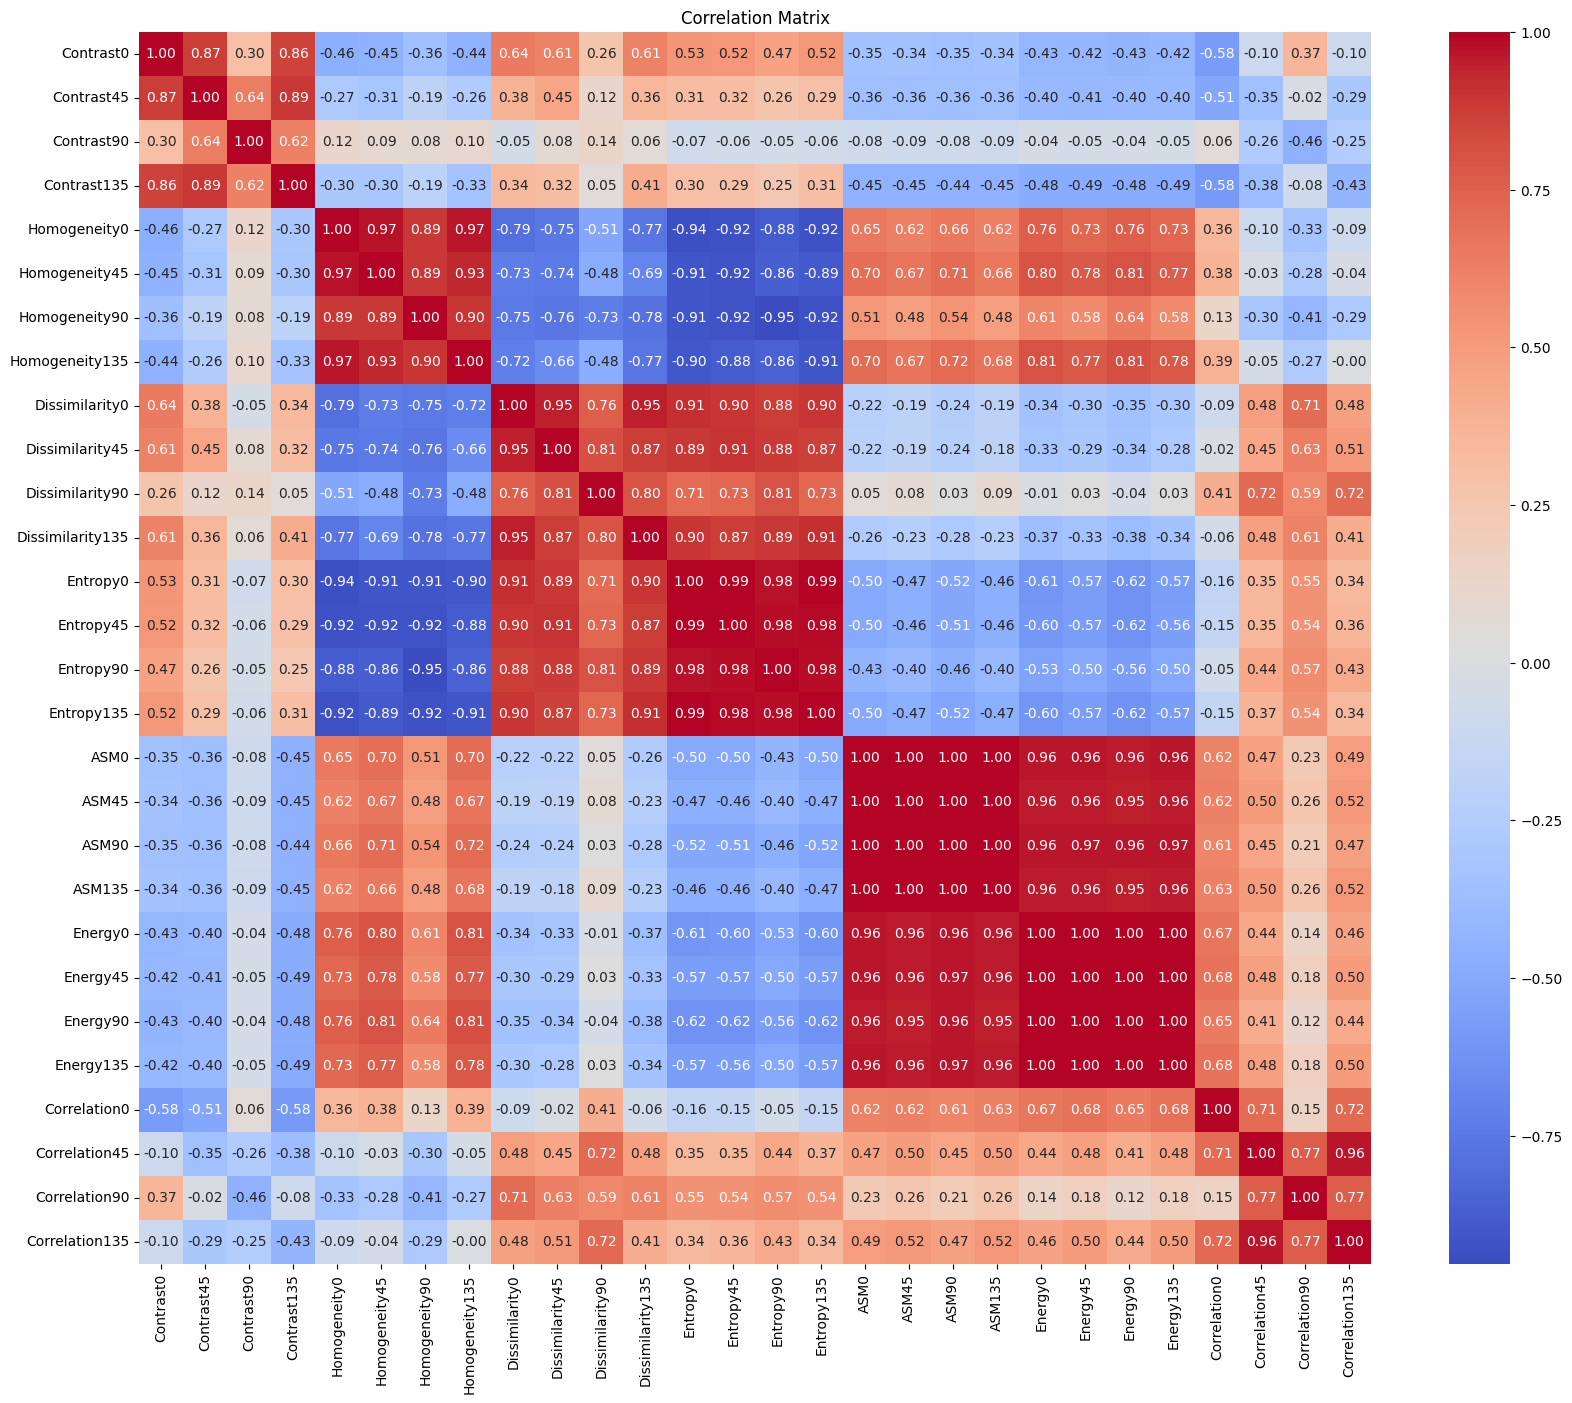

In [42]:
# Baca CSV hasil ekstraksi
hasilEkstrak = pd.read_csv('hasil_ekstraksi_pros2.csv')
hasilEkstrak = hasilEkstrak.drop(columns=['Filename'])

x = hasilEkstrak.drop(columns=['Class'])
y = hasilEkstrak['Class']

# Heatmap korelasi
correlation_matrix = x.corr()
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.savefig('correlation_matrix.png')
plt.show()

#### Pembagian Data Training dan Testing

Tahap ini membagi dataset menjadi data pelatihan dan data pengujian.

Cara Kerja:

* Fungsi `train_test_split()` digunakan untuk membagi data.
* Sebanyak 70% data digunakan untuk training dan 30% untuk testing.
* Jumlah data pada masing-masing subset ditampilkan.

Kenapa Dilakukan?

* Data training digunakan untuk melatih model.
* Data testing digunakan untuk mengevaluasi performa model pada data baru.

In [43]:
# Split data 70/30
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
print(f"Training set size: {len(x_train)}, Test set size: {len(x_test)}")

Training set size: 280, Test set size: 120


In [34]:
def normalize_data(data):
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    normalized_data = (data - mean) / std
    return normalized_data

x_train = normalize_data(x_train)
x_test = normalize_data(x_test)

## Fungsi Normalisasi Data

Tahap ini bertujuan untuk menormalisasi data fitur menggunakan metode **Z-Score Normalization**.

Cara Kerja:

* Fungsi `normalize_data()` menghitung nilai rata-rata (`mean`) dan standar deviasi (`std`) dari setiap fitur.
* Setiap nilai fitur dinormalisasi menggunakan rumus `(data - mean) / std`.
* Fungsi diterapkan pada data training (`x_train`) dan data testing (`x_test`).

Kenapa Dilakukan?

* Untuk menyamakan skala antar fitur.
* Mencegah fitur dengan rentang nilai besar mendominasi proses klasifikasi.
* Membantu meningkatkan performa algoritma seperti SVM dan KNN.


In [35]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

rf  = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

## Fungsi Evaluasi dan Inisialisasi Model Klasifikasi

Tahap ini bertujuan untuk membuat fungsi evaluasi model serta menginisialisasi algoritma klasifikasi yang akan digunakan.

Cara Kerja:

* Fungsi `generateClassificationReport()` digunakan untuk menampilkan hasil evaluasi berupa **classification report**, **confusion matrix**, dan **accuracy score**.
* Model **Random Forest** diinisialisasi dengan `n_estimators=5`.
* Model **Support Vector Machine (SVM)** diinisialisasi menggunakan kernel `rbf`.
* Model **K-Nearest Neighbors (KNN)** diinisialisasi dengan jumlah tetangga terdekat (`n_neighbors`) sebanyak 5.

Kenapa Dilakukan?

* Untuk memudahkan evaluasi performa model klasifikasi.
* Menggunakan beberapa algoritma klasifikasi untuk membandingkan hasil yang diperoleh.
* Menentukan model dengan performa terbaik berdasarkan metrik evaluasi yang digunakan.


### Train Random Forest Classifier

In [45]:
# Random Forest
rf.fit(x_train, y_train)
print("------Training Set------")
generateClassificationReport(y_train, rf.predict(x_train))
print("\n------Testing Set------")
generateClassificationReport(y_test, rf.predict(x_test))

------Training Set------
                precision    recall  f1-score   support

        Blight       0.95      0.95      0.95        63
   Common_Rust       1.00      1.00      1.00        75
Gray_Leaf_Spot       0.97      0.96      0.96        70
       Healthy       0.99      1.00      0.99        72

      accuracy                           0.98       280
     macro avg       0.98      0.98      0.98       280
  weighted avg       0.98      0.98      0.98       280

[[60  0  2  1]
 [ 0 75  0  0]
 [ 3  0 67  0]
 [ 0  0  0 72]]
Accuracy: 0.9785714285714285

------Testing Set------
                precision    recall  f1-score   support

        Blight       0.85      0.76      0.80        37
   Common_Rust       1.00      1.00      1.00        25
Gray_Leaf_Spot       0.69      0.90      0.78        30
       Healthy       1.00      0.82      0.90        28

      accuracy                           0.86       120
     macro avg       0.89      0.87      0.87       120
  weighted avg 

### Train SVM Classifier

In [44]:
# SVM
svm.fit(x_train, y_train)
print("------Training Set------")
generateClassificationReport(y_train, svm.predict(x_train))
print("\n------Testing Set------")
generateClassificationReport(y_test, svm.predict(x_test))

------Training Set------
                precision    recall  f1-score   support

        Blight       0.46      0.10      0.16        63
   Common_Rust       0.53      0.87      0.66        75
Gray_Leaf_Spot       0.50      0.73      0.59        70
       Healthy       0.74      0.44      0.56        72

      accuracy                           0.55       280
     macro avg       0.56      0.53      0.49       280
  weighted avg       0.56      0.55      0.50       280

[[ 6 12 41  4]
 [ 2 65  4  4]
 [ 5 11 51  3]
 [ 0 34  6 32]]
Accuracy: 0.55

------Testing Set------
                precision    recall  f1-score   support

        Blight       0.50      0.05      0.10        37
   Common_Rust       0.46      0.96      0.62        25
Gray_Leaf_Spot       0.46      0.77      0.57        30
       Healthy       1.00      0.50      0.67        28

      accuracy                           0.53       120
     macro avg       0.61      0.57      0.49       120
  weighted avg       0.60    

### Train KNN Classifier

In [46]:
# KNN
knn.fit(x_train, y_train)
print("------Training Set------")
generateClassificationReport(y_train, knn.predict(x_train))
print("\n------Testing Set------")
generateClassificationReport(y_test, knn.predict(x_test))

------Training Set------
                precision    recall  f1-score   support

        Blight       0.63      0.62      0.62        63
   Common_Rust       0.88      0.93      0.90        75
Gray_Leaf_Spot       0.69      0.71      0.70        70
       Healthy       0.82      0.75      0.78        72

      accuracy                           0.76       280
     macro avg       0.75      0.75      0.75       280
  weighted avg       0.76      0.76      0.76       280

[[39  2 17  5]
 [ 3 70  0  2]
 [14  1 50  5]
 [ 6  7  5 54]]
Accuracy: 0.7607142857142857

------Testing Set------
                precision    recall  f1-score   support

        Blight       0.60      0.57      0.58        37
   Common_Rust       0.79      0.88      0.83        25
Gray_Leaf_Spot       0.56      0.50      0.53        30
       Healthy       0.83      0.89      0.86        28

      accuracy                           0.69       120
     macro avg       0.69      0.71      0.70       120
  weighted avg 

## Evaluation With Confusion Matrix

##### Evaluasi Model dengan Confusion Matrix

Kode ini berfungsi untuk menampilkan **confusion matrix** dari hasil prediksi model terhadap data uji.

Fungsi `plot_confusion_matrix`

* Menghitung confusion matrix dari data aktual (`y_true`) dan hasil prediksi (`y_pred`).
* Menampilkan confusion matrix menggunakan `ConfusionMatrixDisplay`.
* Memberikan judul sesuai parameter `title` dan menampilkan visualisasi confusion matrix.

Penggunaan:

* Menampilkan confusion matrix untuk model **Random Forest** menggunakan data uji.
* Menampilkan confusion matrix untuk model **SVM** menggunakan data uji.
* Menampilkan confusion matrix untuk model **KNN** menggunakan data uji.

Confusion matrix ini membantu melihat secara rinci jumlah prediksi yang benar maupun salah pada setiap kelas, sehingga performa masing-masing model dapat dievaluasi dengan lebih baik.

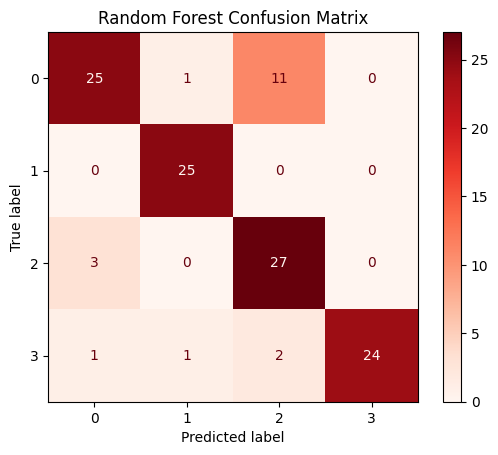

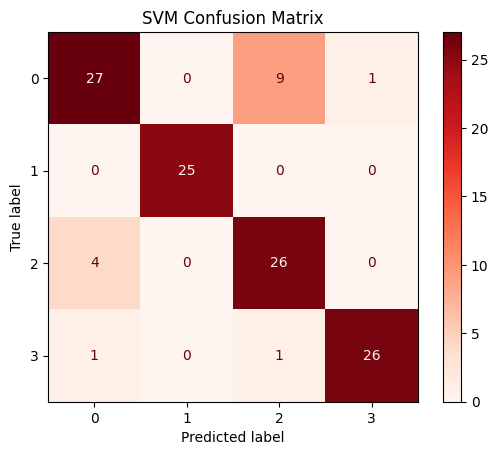

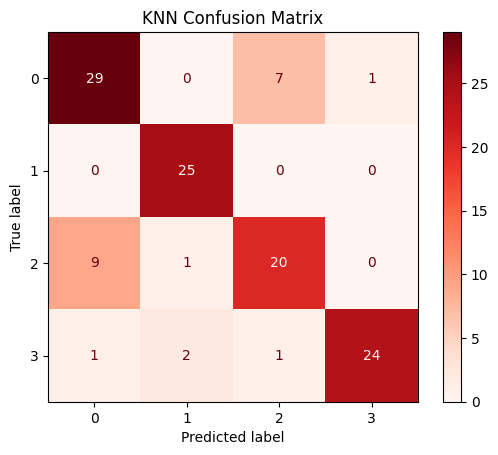

In [37]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Reds)
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_test, rf.predict(x_test),  "Random Forest Confusion Matrix")
plot_confusion_matrix(y_test, svm.predict(x_test), "SVM Confusion Matrix")
plot_confusion_matrix(y_test, knn.predict(x_test), "KNN Confusion Matrix")

##### Perbandingan Performa Model Klasifikasi

Kode dibawah untuk menampilkan **tabel perbandingan performa** dari model Random Forest, SVM, dan KNN berdasarkan beberapa metrik evaluasi.

Fungsi `display_model_comparison` menerima empat parameter utama, yaitu `y_true` sebagai label sebenarnya dari data uji, serta `rf_pred`, `svm_pred`, dan `knn_pred` yang merupakan hasil prediksi dari masing-masing model. Nama model yang akan ditampilkan secara default adalah **Random Forest**, **SVM**, dan **KNN**.

Terdapat empat metrik evaluasi yang digunakan, yaitu **Accuracy**, **Precision**, **Recall**, dan **F1-Score**. Setiap metrik dikaitkan dengan fungsi evaluasinya masing-masing dari library `sklearn.metrics`. Selanjutnya, dilakukan iterasi untuk setiap model beserta hasil prediksinya guna menghitung seluruh metrik evaluasi tersebut.

Untuk metrik **Precision**, **Recall**, dan **F1-Score**, digunakan parameter `average='weighted'` agar evaluasi dapat dilakukan dengan baik pada kasus klasifikasi multikelas (*multiclass classification*). Sementara itu, **Accuracy** dihitung menggunakan fungsi evaluasi standar tanpa parameter tambahan.

Hasil perhitungan setiap metrik disimpan ke dalam dictionary `comparison_data`. Data tersebut kemudian dikonversi menjadi `pandas.DataFrame` dan ditransposisikan (`.T`) sehingga nama model ditampilkan sebagai baris dan metrik evaluasi sebagai kolom. Terakhir, tabel perbandingan performa model ditampilkan menggunakan fungsi `display()`.

Kode ini membantu dalam membandingkan performa ketiga model klasifikasi sehingga dapat diketahui model mana yang memberikan hasil terbaik berdasarkan metrik evaluasi yang digunakan.


In [38]:
def display_model_comparison(y_true, rf_pred, svm_pred, knn_pred, model_names=['Random Forest', 'SVM', 'KNN']):
    metrics = {
        'Accuracy':  accuracy_score,
        'Precision': precision_score,
        'Recall':    recall_score,
        'F1-Score':  f1_score
    }
    comparison_data = {}
    for name, pred in zip(model_names, [rf_pred, svm_pred, knn_pred]):
        comparison_data[name] = {}
        for metric_name, metric_func in metrics.items():
            if metric_name in ['Precision', 'Recall', 'F1-Score']:
                comparison_data[name][metric_name] = metric_func(y_true, pred, average='weighted')
            else:
                comparison_data[name][metric_name] = metric_func(y_true, pred)

    df_comparison = pd.DataFrame(comparison_data).T
    print("\nTABEL PERBANDINGAN MODEL")
    display(df_comparison)

rf_pred  = rf.predict(x_test)
svm_pred = svm.predict(x_test)
knn_pred = knn.predict(x_test)
display_model_comparison(y_test, rf_pred, svm_pred, knn_pred)


TABEL PERBANDINGAN MODEL


,Accuracy,Precision,Recall,F1-Score
Random Forest,0.841667,0.860789,0.841667,0.842148
SVM,0.866667,0.873736,0.866667,0.867213
KNN,0.816667,0.817857,0.816667,0.815582


##### Perbandingan Performa Model Klasifikasi dengan Persenan (%)

In [41]:
def display_model_comparison(y_true, rf_pred, svm_pred, knn_pred, model_names=['Random Forest', 'SVM', 'KNN']):
    metrics = {
        'Accuracy':  accuracy_score,
        'Precision': precision_score,
        'Recall':    recall_score,
        'F1-Score':  f1_score
    }
    comparison_data = {}
    for name, pred in zip(model_names, [rf_pred, svm_pred, knn_pred]):
        comparison_data[name] = {}
        for metric_name, metric_func in metrics.items():
            if metric_name in ['Precision', 'Recall', 'F1-Score']:
                score = metric_func(y_true, pred, average='weighted')
            else:
                score = metric_func(y_true, pred)
            
            # kalikan 100 dan format jadi persen
            comparison_data[name][metric_name] = f"{score * 100:.2f}%"

    df_comparison = pd.DataFrame(comparison_data).T
    print("\nTABEL PERBANDINGAN MODEL")
    display(df_comparison)

rf_pred  = rf.predict(x_test)
svm_pred = svm.predict(x_test)
knn_pred = knn.predict(x_test)
display_model_comparison(y_test, rf_pred, svm_pred, knn_pred)


TABEL PERBANDINGAN MODEL


,Accuracy,Precision,Recall,F1-Score
Random Forest,84.17%,86.08%,84.17%,84.21%
SVM,86.67%,87.37%,86.67%,86.72%
KNN,81.67%,81.79%,81.67%,81.56%


##### Analisis Hasil Perbandingan Model Klasifikasi

Berdasarkan hasil evaluasi yang diperoleh, model SVM (Support Vector Machine) menunjukkan performa terbaik dibandingkan Random Forest dan KNN. Hal ini terlihat dari nilai Accuracy sebesar **86,67%**, yang merupakan nilai tertinggi di antara ketiga model. Selain itu, SVM juga memiliki nilai Precision (**87,37%**), Recall (**86,67%**), dan F1-Score (**86,72%**) tertinggi, yang menunjukkan bahwa model ini mampu melakukan klasifikasi dengan tingkat ketepatan dan keseimbangan performa yang baik pada seluruh kelas.

Model Random Forest menempati posisi kedua dengan nilai Accuracy sebesar **84,17%**, Precision **86,08%**, Recall **84,17%**, dan F1-Score **84,21%**. Nilai Precision yang cukup tinggi menunjukkan bahwa Random Forest cukup baik dalam menghasilkan prediksi yang tepat, meskipun performanya masih sedikit di bawah SVM.

Sementara itu, model K-Nearest Neighbors (KNN) memiliki performa paling rendah dibandingkan dua model lainnya, dengan nilai Accuracy sebesar **81,67%**, Precision **81,79%**, Recall **81,67%**, dan F1-Score **81,56%**. Hal ini menunjukkan bahwa KNN kurang optimal dalam mengenali pola pada dataset yang digunakan.

Secara keseluruhan, berdasarkan keempat metrik evaluasi yang digunakan, SVM merupakan model terbaik untuk klasifikasi pada penelitian ini karena memberikan nilai Accuracy, Precision, Recall, dan F1-Score tertinggi. Oleh karena itu, SVM dapat dipertimbangkan sebagai model yang paling efektif untuk digunakan pada dataset hasil ekstraksi fitur GLCM yang telah dibangun.